# 1 - Inicialização

In [130]:
# Carregando todas as bibliotecas
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats as st

# 2 - Carregue os dados

In [131]:
result_01 = pd.read_csv('/datasets/project_sql_result_01.csv')

In [132]:
result_04 = pd.read_csv('/datasets/project_sql_result_04.csv')

In [133]:
result_07 = pd.read_csv('/datasets/project_sql_result_07.csv')

# 3 - Verificar os DFs

## 3.1 - result_01

In [134]:
result_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [135]:
result_01.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


Este DataFrame possui apenas 2 colunas, que são:
- company_name (nome de cada empresa de taxi)
- trips_amount (o número de corridas para cada empresa de táxi de 15 a 16 de novembro de 2017)

# 3.2 - result_04

In [136]:
result_04.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [137]:
result_04.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


Este DataFrame possui apenas 2 colunas, que são:
- dropoff_location_name (bairros de Chicago onde as corridas terminaram)
- average_trips (o número médio de viagens que terminaram em cada bairro em novembro de 2017)

## 3.3 - result_07

In [138]:
result_07.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [139]:
result_07.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [140]:
# Alterando o tipo da coluna
result_07['start_ts'] = pd.to_datetime(result_07['start_ts'])

Este DataFrame possui apenas 3 colunas, que são:
- start_ts (data e hora da coleta)
- weather_conditions (condições meteorológicas no momento em que a corrida começou)
- duration_seconds (duração da corrida em segundos)

Foi alterado o tipo da coluna start_ts para datetime

# 4 - Analisando os DF

## 4.1 - Identificando os 10 principais bairros em relação ao destino

In [141]:
top_10_location = result_04.sort_values(by='average_trips', ascending=False).head(10)
top_10_location

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


# 4.2 - Identificando as 10 principais empresas

In [142]:
top_10_company = result_01.sort_values(by='trips_amount', ascending=False).head(10)
top_10_company

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


## 4.3 - Criação de gráficos

### 4.3.1 - Gráfico: empresas de táxi e número de corridas

Text(0, 0.5, 'Empresas de Taxi')

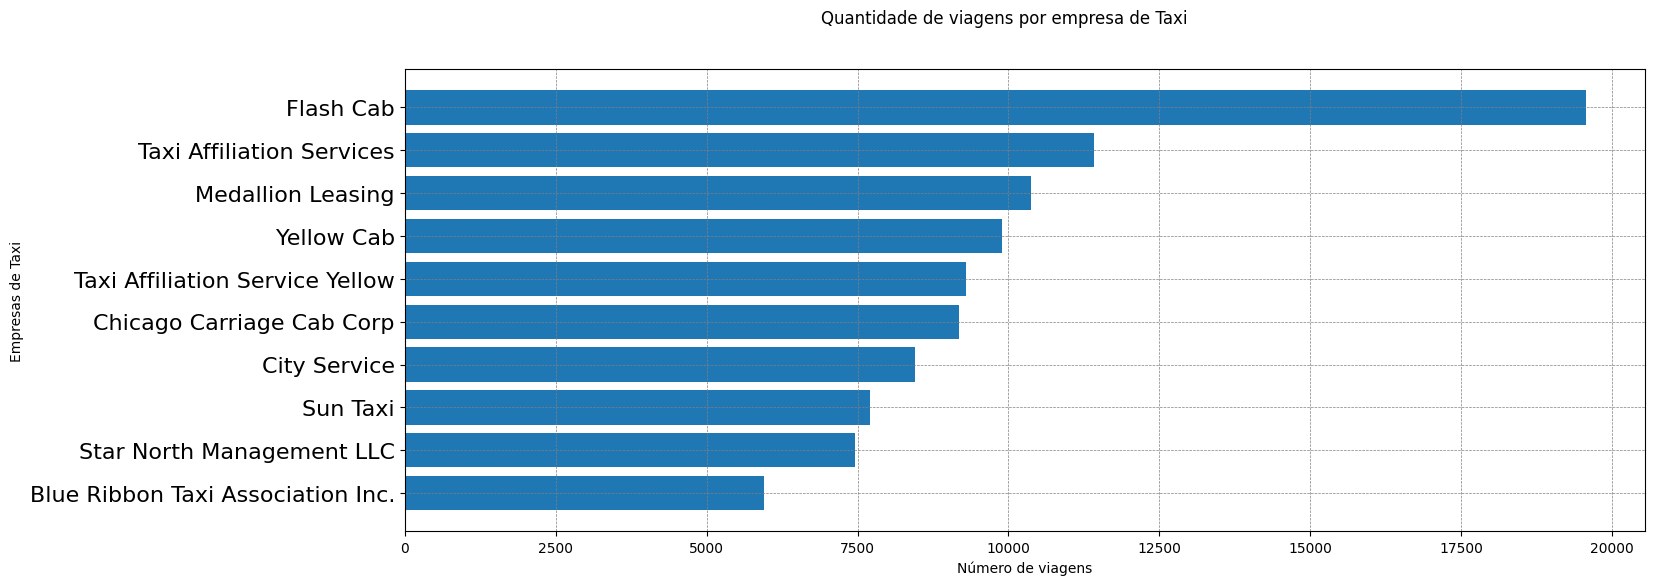

In [143]:
# criando a figura
fig, ax = plt.subplots(figsize=(16,6))

# plotando o gráfico
ax.barh(top_10_company['company_name'], top_10_company['trips_amount'])
ax.invert_yaxis()

# ajustando do gráfico
fig.suptitle('Quantidade de viagens por empresa de Taxi')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.yticks(fontsize=16)
plt.xlabel('Número de viagens')
plt.ylabel('Empresas de Taxi')

### 4.3.2 - Gráfico: top 10 bairros por número de corridas em que esse bairro é destino

Text(0, 0.5, 'Bairros')

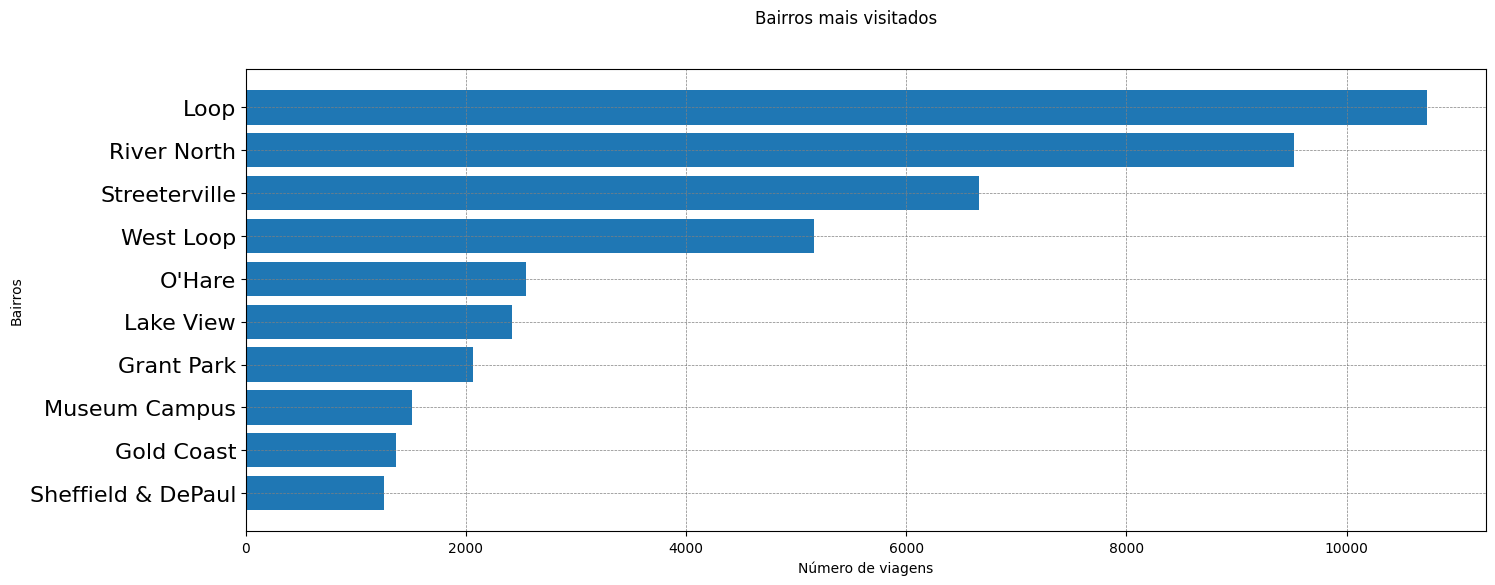

In [144]:
# criando a figura
fig, ax = plt.subplots(figsize=(16,6))

# plotando o gráfico
ax.barh(top_10_location['dropoff_location_name'], top_10_location['average_trips'])
ax.invert_yaxis()

# ajustando do gráfico
fig.suptitle('Bairros mais visitados')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.yticks(fontsize=16)
plt.xlabel('Número de viagens')
plt.ylabel('Bairros')

## 4.4 - Conclusão

Observa-se que a empresa Flash Cab se destaca com seu número elevado de viagens. Em relação as outras empresas, elas estão no patamar entre 7.500 e 10.000 viagens (aproximadamente).

Os bairros que mais se destacam em relação a receber viagens são: Loop e River North. Estes estão acompanhados de Streeterville e West Loop. 
Os demais bairros possuem um valor inferior de viagens, mas ainda assim estão entre os mais visitados. Tendo um número de viagens proximo a 2000.

# 5 - Teste de Hipótese

### Hipótese  nula:

A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare são **IGUAIS** em sábados chuvosos.

### Hipótese  alternativa:

A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare são **DIFERENTES** em sábados chuvosos.

In [145]:
# Separando a classificação de cada 'weather_conditions'

# Para tempo 'Good'
weather_good = result_07[result_07['weather_conditions'] == 'Good']
saturdays_good = weather_good[weather_good['start_ts'].dt.dayofweek == 5]['duration_seconds']

# Para tempo 'Bad'
weather_bad = result_07[result_07['weather_conditions'] == 'Bad']
saturdays_bad = weather_bad[weather_bad['start_ts'].dt.dayofweek == 5]['duration_seconds']

In [148]:
# comparar a variancia
saturdays_good.var(), saturdays_bad.var()

(576382.009689509, 520294.086002483)

In [147]:
# Teste

alpha = 0.05

results = st.ttest_ind(saturdays_good, saturdays_bad, equal_var=False) # variancia diferente, equal_var=False
print('valor-p: ',results.pvalue)

if results.pvalue < alpha:
    print('Rejeitamos a hipótese nula!')
else:
    print('Não podemos rejeitar a hipótese nula!')

valor-p:  6.738994326108734e-12
Rejeitamos a hipótese nula!


# Conclusão

#### Existem evidências fortes de que a duração média dos passeios do Loop para o Aeroporto Internacional O'Hare são diferentes em sábados chuvosos

Critério de Teste Escolhido:
Teste t de Student para duas amostras independentes
1. Tipo de dados:
- Variável numérica contínua (duração em segundos)
- Duas amostras independentes (sábados com/sem chuva)

2. Objetivo:
- Comparar médias de dois grupos
- Determinar se a diferença é estatisticamente significativa

3. Pressupostos:
- Amostras independentes ✓
- Distribuição aproximadamente normal (ou n > 30)
- Variâncias podem ser diferentes (usar Welch's t-test)